In [475]:
import pyforest

In [476]:
df =  pd.read_csv('/Users/abdulsubhan/Downloads/Copy of Sample_DATA.csv')

In [477]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [478]:
df.head()

,Transaction_ID,Date,Time,Merchant_ID,Customer_ID,Device_ID,Transaction_Type,Payment_Gateway,Transaction_City,Transaction_State,IP_Address,Transaction_Status,Device_OS,Transaction_Frequency,Merchant_Category,Transaction_Channel,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud
0,T00022452,20/04/23,4:50:22 AM,f65a902b-2396-40cc-9593-97e103f1bc15,89aaeceb-21f5-46c8-9de3-89dde6a10a75,c1e0deb4-7c97-4178-a838-38f4a2f0b57c,Refund,SamplePay,Durgapur,Chhattisgarh,140.213.7.48,Completed,MacOS,1,Brand Vouchers and OTT,In-store,25.02,5,396.62,1
1,T00032233,08/08/23,8:09:21 AM,d4a5efcb-4eb6-4d3a-8132-07bb3e6e13a4,8a8962f9-e84a-4573-ab0b-187311978a21,62e14f64-b0ba-4284-889a-51ac05baf33e,Bank Transfer,SamplePay,Rajpur Sonarpur,Himachal Pradesh,184.108.177.45,Pending,Windows,30,Home delivery,Mobile,-36.64,20,121.94,1
2,T00037364,25/06/23,7:49:01 AM,759ad138-9473-4729-8699-3d72c7ffb983,c3f53ce6-e305-4460-a71d-93bde26043ab,4281c542-ac77-4269-b4bb-1de93ac12677,Bank Transfer,Other,New Delhi,Himachal Pradesh,16.106.248.163,Failed,Android,2,Utilities,Online,44.19,22,106.69,1
3,T00015924,28/01/24,5:44:12 AM,d8f561e4-bded-4ef0-bcd8-5494b2e31a94,9f0c5613-7d4c-4454-bee1-c47fbba406a1,058b6488-2469-42f2-bc7f-707921d35cad,Subscription,UPI Pay,Bharatpur,Chhattisgarh,65.245.160.212,Failed,Android,0,Purchases,Online,-54.34,28,3611.11,1
4,T00021805,21/06/23,9:40:59 AM,26fdd7a1-8537-4dfe-bcf7-f5a127b36682,bf9aa6d5-7d3d-43f9-8631-31336720a383,068ff12c-127a-4cfb-9899-ddde37060b28,Investment,Dummy Bank,Sagar,Mizoram,33.172.152.38,Completed,MacOS,1,Other,Online,12.38,25,374.89,1


In [479]:
df.columns

Index(['Transaction_ID', 'Date', 'Time', 'Merchant_ID', 'Customer_ID',
       'Device_ID', 'Transaction_Type', 'Payment_Gateway', 'Transaction_City',
       'Transaction_State', 'IP_Address', 'Transaction_Status', 'Device_OS',
       'Transaction_Frequency', 'Merchant_Category', 'Transaction_Channel',
       'Transaction_Amount_Deviation', 'Days_Since_Last_Transaction', 'amount',
       'fraud'],
      dtype='object')

In [480]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647 entries, 0 to 646
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                647 non-null    object 
 1   Date                          647 non-null    object 
 2   Time                          647 non-null    object 
 3   Merchant_ID                   647 non-null    object 
 4   Customer_ID                   647 non-null    object 
 5   Device_ID                     647 non-null    object 
 6   Transaction_Type              647 non-null    object 
 7   Payment_Gateway               647 non-null    object 
 8   Transaction_City              647 non-null    object 
 9   Transaction_State             647 non-null    object 
 10  IP_Address                    647 non-null    object 
 11  Transaction_Status            647 non-null    object 
 12  Device_OS                     647 non-null    object 
 13  Trans

In [481]:
df.describe()

,Transaction_Frequency,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud
count,647.000000,647.000000,647.000000,647.000000,647.000000
mean,3.564142,5.014668,15.717156,128.839753,0.239567
std,6.454543,56.375914,8.218122,364.995747,0.427150
min,0.000000,-99.470000,1.000000,0.120000,0.000000
25%,1.000000,-42.355000,8.500000,17.155000,0.000000
50%,2.000000,8.380000,16.000000,35.000000,0.000000
75%,3.000000,52.290000,23.000000,74.770000,0.000000
max,50.000000,99.450000,29.000000,4883.620000,1.000000


In [482]:
df.duplicated().sum()

np.int64(0)

In [483]:
df.isnull().sum()

Transaction_ID                  0
Date                            0
Time                            0
Merchant_ID                     0
Customer_ID                     0
Device_ID                       0
Transaction_Type                0
Payment_Gateway                 0
Transaction_City                0
Transaction_State               0
IP_Address                      0
Transaction_Status              0
Device_OS                       0
Transaction_Frequency           0
Merchant_Category               0
Transaction_Channel             0
Transaction_Amount_Deviation    0
Days_Since_Last_Transaction     0
amount                          0
fraud                           0
dtype: int64

In [484]:
df.shape

(647, 20)

In [485]:
df.nunique()

Transaction_ID                  647
Date                            302
Time                            641
Merchant_ID                     647
Customer_ID                     647
Device_ID                       647
Transaction_Type                  7
Payment_Gateway                   9
Transaction_City                281
Transaction_State                28
IP_Address                      647
Transaction_Status                3
Device_OS                         4
Transaction_Frequency            14
Merchant_Category                10
Transaction_Channel               3
Transaction_Amount_Deviation    635
Days_Since_Last_Transaction      29
amount                          633
fraud                             2
dtype: int64

In [486]:
df.columns

Index(['Transaction_ID', 'Date', 'Time', 'Merchant_ID', 'Customer_ID',
       'Device_ID', 'Transaction_Type', 'Payment_Gateway', 'Transaction_City',
       'Transaction_State', 'IP_Address', 'Transaction_Status', 'Device_OS',
       'Transaction_Frequency', 'Merchant_Category', 'Transaction_Channel',
       'Transaction_Amount_Deviation', 'Days_Since_Last_Transaction', 'amount',
       'fraud'],
      dtype='object')

In [487]:
#drop unique values 
df.drop(
    columns=['Transaction_ID','Merchant_ID' 'Customer_ID', 'Device_ID', 'IP_Address'],
    inplace=True,
    errors='ignore'
)


In [488]:
df.head()

,Date,Time,Merchant_ID,Customer_ID,Transaction_Type,Payment_Gateway,Transaction_City,Transaction_State,Transaction_Status,Device_OS,Transaction_Frequency,Merchant_Category,Transaction_Channel,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud
0,20/04/23,4:50:22 AM,f65a902b-2396-40cc-9593-97e103f1bc15,89aaeceb-21f5-46c8-9de3-89dde6a10a75,Refund,SamplePay,Durgapur,Chhattisgarh,Completed,MacOS,1,Brand Vouchers and OTT,In-store,25.02,5,396.62,1
1,08/08/23,8:09:21 AM,d4a5efcb-4eb6-4d3a-8132-07bb3e6e13a4,8a8962f9-e84a-4573-ab0b-187311978a21,Bank Transfer,SamplePay,Rajpur Sonarpur,Himachal Pradesh,Pending,Windows,30,Home delivery,Mobile,-36.64,20,121.94,1
2,25/06/23,7:49:01 AM,759ad138-9473-4729-8699-3d72c7ffb983,c3f53ce6-e305-4460-a71d-93bde26043ab,Bank Transfer,Other,New Delhi,Himachal Pradesh,Failed,Android,2,Utilities,Online,44.19,22,106.69,1
3,28/01/24,5:44:12 AM,d8f561e4-bded-4ef0-bcd8-5494b2e31a94,9f0c5613-7d4c-4454-bee1-c47fbba406a1,Subscription,UPI Pay,Bharatpur,Chhattisgarh,Failed,Android,0,Purchases,Online,-54.34,28,3611.11,1
4,21/06/23,9:40:59 AM,26fdd7a1-8537-4dfe-bcf7-f5a127b36682,bf9aa6d5-7d3d-43f9-8631-31336720a383,Investment,Dummy Bank,Sagar,Mizoram,Completed,MacOS,1,Other,Online,12.38,25,374.89,1


In [489]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%y')

data cleaning and feature engineering 

In [490]:
df[['Date','amount']]

,Date,amount
0,2023-04-20,396.62
1,2023-08-08,121.94
2,2023-06-25,106.69
3,2024-01-28,3611.11
4,2023-06-21,374.89
...,...,...
642,2023-07-24,28.27
643,2023-07-05,26.26
644,2023-04-16,6.02
645,2023-10-28,17.12


In [491]:
df['Year']= df['Date'].dt.year

In [492]:
df['Month']= df['Date'].dt.month

In [493]:
df.head()

,Date,Time,Merchant_ID,Customer_ID,Transaction_Type,Payment_Gateway,Transaction_City,Transaction_State,Transaction_Status,Device_OS,Transaction_Frequency,Merchant_Category,Transaction_Channel,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud,Year,Month
0,2023-04-20,4:50:22 AM,f65a902b-2396-40cc-9593-97e103f1bc15,89aaeceb-21f5-46c8-9de3-89dde6a10a75,Refund,SamplePay,Durgapur,Chhattisgarh,Completed,MacOS,1,Brand Vouchers and OTT,In-store,25.02,5,396.62,1,2023,4
1,2023-08-08,8:09:21 AM,d4a5efcb-4eb6-4d3a-8132-07bb3e6e13a4,8a8962f9-e84a-4573-ab0b-187311978a21,Bank Transfer,SamplePay,Rajpur Sonarpur,Himachal Pradesh,Pending,Windows,30,Home delivery,Mobile,-36.64,20,121.94,1,2023,8
2,2023-06-25,7:49:01 AM,759ad138-9473-4729-8699-3d72c7ffb983,c3f53ce6-e305-4460-a71d-93bde26043ab,Bank Transfer,Other,New Delhi,Himachal Pradesh,Failed,Android,2,Utilities,Online,44.19,22,106.69,1,2023,6
3,2024-01-28,5:44:12 AM,d8f561e4-bded-4ef0-bcd8-5494b2e31a94,9f0c5613-7d4c-4454-bee1-c47fbba406a1,Subscription,UPI Pay,Bharatpur,Chhattisgarh,Failed,Android,0,Purchases,Online,-54.34,28,3611.11,1,2024,1
4,2023-06-21,9:40:59 AM,26fdd7a1-8537-4dfe-bcf7-f5a127b36682,bf9aa6d5-7d3d-43f9-8631-31336720a383,Investment,Dummy Bank,Sagar,Mizoram,Completed,MacOS,1,Other,Online,12.38,25,374.89,1,2023,6


In [494]:
df['Month'].unique()

df['Month'].sort_values(ascending=True).unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

month columns in 'MMM' format

In [495]:
months = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}
months

{1: 'January',
 2: 'February',
 3: 'March',
 4: 'April',
 5: 'May',
 6: 'June',
 7: 'July',
 8: 'August',
 9: 'September',
 10: 'October',
 11: 'November',
 12: 'December'}

mapping dictionary to month column


In [496]:
df['Month_Name'] = df['Month'].map(months)
df.head()

,Date,Time,Merchant_ID,Customer_ID,Transaction_Type,Payment_Gateway,Transaction_City,Transaction_State,Transaction_Status,Device_OS,Transaction_Frequency,Merchant_Category,Transaction_Channel,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud,Year,Month,Month_Name
0,2023-04-20,4:50:22 AM,f65a902b-2396-40cc-9593-97e103f1bc15,89aaeceb-21f5-46c8-9de3-89dde6a10a75,Refund,SamplePay,Durgapur,Chhattisgarh,Completed,MacOS,1,Brand Vouchers and OTT,In-store,25.02,5,396.62,1,2023,4,April
1,2023-08-08,8:09:21 AM,d4a5efcb-4eb6-4d3a-8132-07bb3e6e13a4,8a8962f9-e84a-4573-ab0b-187311978a21,Bank Transfer,SamplePay,Rajpur Sonarpur,Himachal Pradesh,Pending,Windows,30,Home delivery,Mobile,-36.64,20,121.94,1,2023,8,August
2,2023-06-25,7:49:01 AM,759ad138-9473-4729-8699-3d72c7ffb983,c3f53ce6-e305-4460-a71d-93bde26043ab,Bank Transfer,Other,New Delhi,Himachal Pradesh,Failed,Android,2,Utilities,Online,44.19,22,106.69,1,2023,6,June
3,2024-01-28,5:44:12 AM,d8f561e4-bded-4ef0-bcd8-5494b2e31a94,9f0c5613-7d4c-4454-bee1-c47fbba406a1,Subscription,UPI Pay,Bharatpur,Chhattisgarh,Failed,Android,0,Purchases,Online,-54.34,28,3611.11,1,2024,1,January
4,2023-06-21,9:40:59 AM,26fdd7a1-8537-4dfe-bcf7-f5a127b36682,bf9aa6d5-7d3d-43f9-8631-31336720a383,Investment,Dummy Bank,Sagar,Mizoram,Completed,MacOS,1,Other,Online,12.38,25,374.89,1,2023,6,June


In [497]:
df.drop(['Date','Time'], axis=1, inplace=True)

In [498]:
df['fraud'].value_counts(normalize=True)*100

fraud
0    76.043277
1    23.956723
Name: proportion, dtype: float64

<Axes: xlabel='fraud', ylabel='count'>

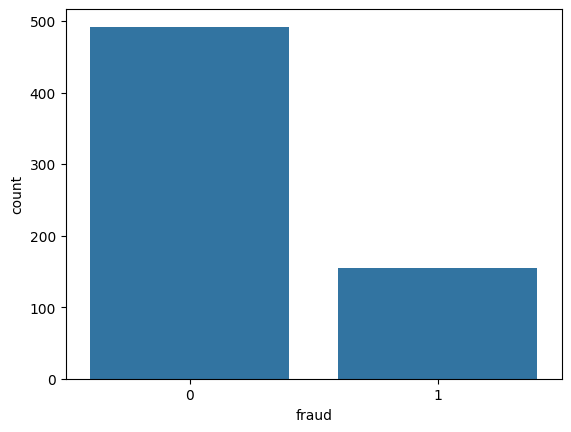

In [499]:
import seaborn as sns
sns.countplot(x='fraud', data=df )

In [500]:
fraud = df[df['fraud']==1]
fraud.head()

,Merchant_ID,Customer_ID,Transaction_Type,Payment_Gateway,Transaction_City,Transaction_State,Transaction_Status,Device_OS,Transaction_Frequency,Merchant_Category,Transaction_Channel,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud,Year,Month,Month_Name
0,f65a902b-2396-40cc-9593-97e103f1bc15,89aaeceb-21f5-46c8-9de3-89dde6a10a75,Refund,SamplePay,Durgapur,Chhattisgarh,Completed,MacOS,1,Brand Vouchers and OTT,In-store,25.02,5,396.62,1,2023,4,April
1,d4a5efcb-4eb6-4d3a-8132-07bb3e6e13a4,8a8962f9-e84a-4573-ab0b-187311978a21,Bank Transfer,SamplePay,Rajpur Sonarpur,Himachal Pradesh,Pending,Windows,30,Home delivery,Mobile,-36.64,20,121.94,1,2023,8,August
2,759ad138-9473-4729-8699-3d72c7ffb983,c3f53ce6-e305-4460-a71d-93bde26043ab,Bank Transfer,Other,New Delhi,Himachal Pradesh,Failed,Android,2,Utilities,Online,44.19,22,106.69,1,2023,6,June
3,d8f561e4-bded-4ef0-bcd8-5494b2e31a94,9f0c5613-7d4c-4454-bee1-c47fbba406a1,Subscription,UPI Pay,Bharatpur,Chhattisgarh,Failed,Android,0,Purchases,Online,-54.34,28,3611.11,1,2024,1,January
4,26fdd7a1-8537-4dfe-bcf7-f5a127b36682,bf9aa6d5-7d3d-43f9-8631-31336720a383,Investment,Dummy Bank,Sagar,Mizoram,Completed,MacOS,1,Other,Online,12.38,25,374.89,1,2023,6,June


In [501]:
df.fraud.value_counts() 

fraud
0    492
1    155
Name: count, dtype: int64

In [502]:
df.shape

(647, 18)

In [503]:
normal = df[df['fraud']==0]

In [504]:
normal.shape

(492, 18)

analyzing the fraud dataset


In [505]:
fraud .head()

,Merchant_ID,Customer_ID,Transaction_Type,Payment_Gateway,Transaction_City,Transaction_State,Transaction_Status,Device_OS,Transaction_Frequency,Merchant_Category,Transaction_Channel,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud,Year,Month,Month_Name
0,f65a902b-2396-40cc-9593-97e103f1bc15,89aaeceb-21f5-46c8-9de3-89dde6a10a75,Refund,SamplePay,Durgapur,Chhattisgarh,Completed,MacOS,1,Brand Vouchers and OTT,In-store,25.02,5,396.62,1,2023,4,April
1,d4a5efcb-4eb6-4d3a-8132-07bb3e6e13a4,8a8962f9-e84a-4573-ab0b-187311978a21,Bank Transfer,SamplePay,Rajpur Sonarpur,Himachal Pradesh,Pending,Windows,30,Home delivery,Mobile,-36.64,20,121.94,1,2023,8,August
2,759ad138-9473-4729-8699-3d72c7ffb983,c3f53ce6-e305-4460-a71d-93bde26043ab,Bank Transfer,Other,New Delhi,Himachal Pradesh,Failed,Android,2,Utilities,Online,44.19,22,106.69,1,2023,6,June
3,d8f561e4-bded-4ef0-bcd8-5494b2e31a94,9f0c5613-7d4c-4454-bee1-c47fbba406a1,Subscription,UPI Pay,Bharatpur,Chhattisgarh,Failed,Android,0,Purchases,Online,-54.34,28,3611.11,1,2024,1,January
4,26fdd7a1-8537-4dfe-bcf7-f5a127b36682,bf9aa6d5-7d3d-43f9-8631-31336720a383,Investment,Dummy Bank,Sagar,Mizoram,Completed,MacOS,1,Other,Online,12.38,25,374.89,1,2023,6,June


In [506]:
fraud.dtypes   

Merchant_ID                      object
Customer_ID                      object
Transaction_Type                 object
Payment_Gateway                  object
Transaction_City                 object
Transaction_State                object
Transaction_Status               object
Device_OS                        object
Transaction_Frequency             int64
Merchant_Category                object
Transaction_Channel              object
Transaction_Amount_Deviation    float64
Days_Since_Last_Transaction       int64
amount                          float64
fraud                             int64
Year                              int32
Month                             int32
Month_Name                       object
dtype: object

In [507]:
numeric_columns = fraud.select_dtypes(include=['int64', 'int32','float'])

In [508]:
cat_columns = fraud.select_dtypes(include=['object'])

In [509]:
numeric_columns.corr()

,Transaction_Frequency,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud,Year,Month
Transaction_Frequency,1.000000,0.112079,0.048399,-0.047628,NaN,-0.068477,0.050947
Transaction_Amount_Deviation,0.112079,1.000000,-0.057579,-0.034097,NaN,-0.005956,-0.012402
Days_Since_Last_Transaction,0.048399,-0.057579,1.000000,0.078918,NaN,-0.003681,-0.010264
amount,-0.047628,-0.034097,0.078918,1.000000,NaN,0.022114,-0.028705
fraud,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,-0.068477,-0.005956,-0.003681,0.022114,NaN,1.000000,-0.800255
Month,0.050947,-0.012402,-0.010264,-0.028705,NaN,-0.800255,1.000000


visualizing entire dataset

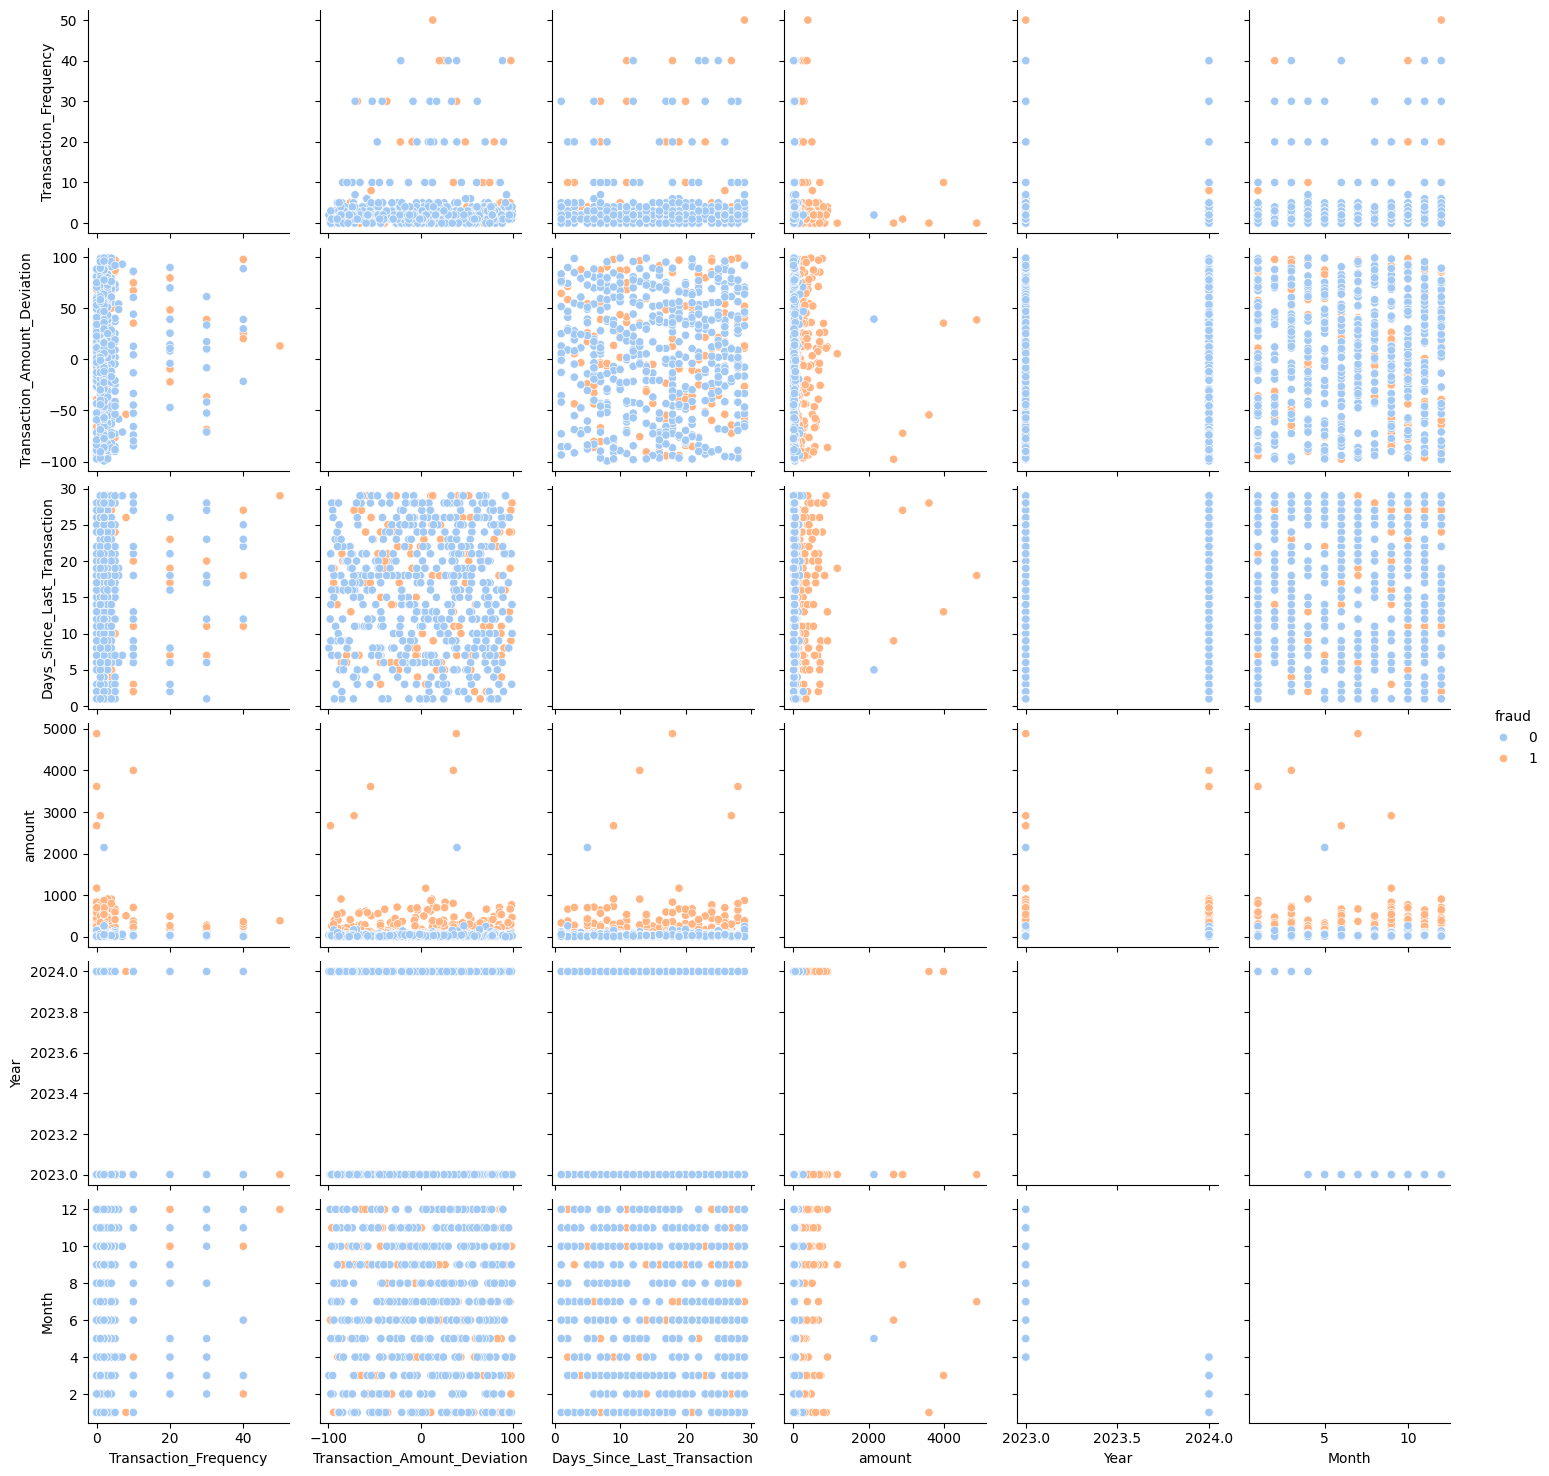

In [510]:
sns.pairplot(data=df , hue = 'fraud' , palette = 'pastel' ,diag_kind = 'dist')

In [511]:
fraud.columns

Index(['Merchant_ID', 'Customer_ID', 'Transaction_Type', 'Payment_Gateway',
       'Transaction_City', 'Transaction_State', 'Transaction_Status',
       'Device_OS', 'Transaction_Frequency', 'Merchant_Category',
       'Transaction_Channel', 'Transaction_Amount_Deviation',
       'Days_Since_Last_Transaction', 'amount', 'fraud', 'Year', 'Month',
       'Month_Name'],
      dtype='object')

In [512]:
pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


In [513]:
 #Plot 1: Fraud distribution by Transaction Type
fig = px.bar(x=fraud['Transaction_Type'].value_counts().index,
    y=fraud['Transaction_Type'].value_counts().values,
    color=fraud['Transaction_Type'].value_counts().index,
    title='Fraud Distribution by Transaction Type',
    labels={'x': 'Transaction Type', 'Transaction_Type': 'Fraud Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()

In [514]:
# Plot 2: Fraud distribution by Payment Gateway
fig = px.bar(
    x=fraud['Payment_Gateway'].value_counts().index,
    y=fraud['Payment_Gateway'].value_counts().values,
    color=fraud['Payment_Gateway'].value_counts().index,
    title='Fraud Distribution by Payment Gateway',
    labels={'x': 'Payment Gateway', 'Payment_Gateway': 'Fraud Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()

In [515]:
# Plot 3: Fraud distribution by Merchant Category


fig = px.bar(
    x=fraud['Merchant_Category'].value_counts().index,
    y=fraud['Merchant_Category'].value_counts().values,
    color=fraud['Merchant_Category'].value_counts().index,
    title='Fraud Distribution by Merchant Category',
    labels={'x': 'Merchant Category', 'y': 'Fraud Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()


In [516]:
# Plot 4: Distribution of Transaction Amount
fig = px.histogram(
    fraud,
    x='amount',
    nbins=20,
    title='Distribution of Transaction Amount',
    labels={'amount': 'Transaction Amount'}
)
fig.show()

In [517]:

# Plot 5: Relationship between Transaction Frequency and Fraud
fig = px.scatter(
    fraud,
    x='Transaction_Frequency',
    y='fraud',
    title='Relationship Between Transaction Frequency and Fraud',
    labels={'Transaction_Frequency': 'Transaction Frequency', 'fraud': 'Fraud'},
    color='fraud',
    color_discrete_map={0: 'lightblue', 1: 'orange'},
    opacity=0.6
)
fig.show()


In [518]:
# Plot 6: Relationship between Days Since Last Transaction and Fraud
fig = px.scatter(
    fraud,
    x='Days_Since_Last_Transaction',
    y='fraud',
    title='Relationship Between Days Since Last Transaction and Fraud',
    labels={'Days_Since_Last_Transaction': 'Days Since Last Transaction', 'fraud': 'Fraud'},
    color='fraud',
    color_discrete_map={0: 'lightblue', 1: 'orange'}
)
fig.show()


In [519]:
# Plot 7: Fraud distribution by Transaction State
fig = px.bar(
    x=fraud['Transaction_State'].value_counts().index,
    y=fraud['Transaction_State'].value_counts().values,
    color=fraud['Transaction_State'].value_counts().index,
    title='Fraud Distribution by Transaction State',
    labels={'x': 'Transaction State', 'y': 'Fraud Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()


In [520]:
# Plot 8: Fraud distribution by Device OS
fig = px.bar(
    x=fraud['Device_OS'].value_counts().index,
    y=fraud['Device_OS'].value_counts().values,
    color=fraud['Device_OS'].value_counts().index,
    title='Fraud Distribution by Device OS',
    labels={'x': 'Device OS', 'y': 'Fraud Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()

In [521]:
columns_to_drop = [
    'Days_Since_Last_Transaction',
    'Transaction_Amount_Deviation',
    'Transaction_Frequency',
    'Transaction_Status',
    'Transaction_City'
]

fraud.drop(columns=columns_to_drop, inplace=True, errors='ignore')


/var/folders/cs/06pk1l757wq6wsgssnj9rzn00000gn/T/ipykernel_26490/2784035948.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [522]:

columns_to_drop = [
    'Days_Since_Last_Transaction',
    'Transaction_Amount_Deviation',
    'Transaction_Frequency',
    'Transaction_Status',
    'Transaction_City',
    'Merchant_ID',
    'Customer_ID',
    'Month_Name'
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [523]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647 entries, 0 to 646
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaction_Type     647 non-null    object 
 1   Payment_Gateway      647 non-null    object 
 2   Transaction_State    647 non-null    object 
 3   Device_OS            647 non-null    object 
 4   Merchant_Category    647 non-null    object 
 5   Transaction_Channel  647 non-null    object 
 6   amount               647 non-null    float64
 7   fraud                647 non-null    int64  
 8   Year                 647 non-null    int32  
 9   Month                647 non-null    int32  
dtypes: float64(1), int32(2), int64(1), object(6)
memory usage: 45.6+ KB


In [524]:
data = df.copy()

In [525]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647 entries, 0 to 646
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaction_Type     647 non-null    object 
 1   Payment_Gateway      647 non-null    object 
 2   Transaction_State    647 non-null    object 
 3   Device_OS            647 non-null    object 
 4   Merchant_Category    647 non-null    object 
 5   Transaction_Channel  647 non-null    object 
 6   amount               647 non-null    float64
 7   fraud                647 non-null    int64  
 8   Year                 647 non-null    int32  
 9   Month                647 non-null    int32  
dtypes: float64(1), int32(2), int64(1), object(6)
memory usage: 45.6+ KB


In [526]:
#converting year column to object
data['Year'] = data['Year'].astype('object')

In [527]:
#extracting categorical columns from data
categorical_cols = data.select_dtypes(include=['object']).columns
categorical_cols 

Index(['Transaction_Type', 'Payment_Gateway', 'Transaction_State', 'Device_OS',
       'Merchant_Category', 'Transaction_Channel', 'Year'],
      dtype='object')

In [528]:
from sklearn.preprocessing import LabelEncoder
cols = ['Year','Month']

LabelEncoder=LabelEncoder()
for col in cols:
    data[col] = LabelEncoder.fit_transform(data[col])

In [529]:
#non ordinal variables
non_ordinal = ['Transaction_Type','Payment_Gateway','Transaction_State','Merchant_Category'] 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647 entries, 0 to 646
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaction_Type     647 non-null    object 
 1   Payment_Gateway      647 non-null    object 
 2   Transaction_State    647 non-null    object 
 3   Device_OS            647 non-null    object 
 4   Merchant_Category    647 non-null    object 
 5   Transaction_Channel  647 non-null    object 
 6   amount               647 non-null    float64
 7   fraud                647 non-null    int64  
 8   Year                 647 non-null    int64  
 9   Month                647 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 50.7+ KB


In [530]:
non_ordinal = [
    'Transaction_Type',
    'Payment_Gateway',
    'Transaction_State',
    'Merchant_Category'
]

existing_cols = [col for col in non_ordinal if col in data.columns]
print("Encoding columns:", existing_cols)


Encoding columns: ['Transaction_Type', 'Payment_Gateway', 'Transaction_State', 'Merchant_Category']


In [531]:
data = pd.get_dummies(
    data,
    columns=existing_cols,
    drop_first=True
)


In [532]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)


In [533]:
import pandas as pd

# clean column names
data.columns = data.columns.str.strip()

non_ordinal = [
    'Transaction_Type',
    'Payment_Gateway',
    'Transaction_State',
    'Merchant_Category'
]

# keep only existing columns
existing_cols = [col for col in non_ordinal if col in data.columns]

# one hot encoding
data = pd.get_dummies(data, columns=existing_cols, drop_first=True)

# convert boolean to int
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)


In [534]:
data.dtypes

Device_OS                                          object
Transaction_Channel                                object
amount                                            float64
fraud                                               int64
Year                                                int64
Month                                               int64
Transaction_Type_Bill Payment                       int64
Transaction_Type_Investment                         int64
Transaction_Type_Other                              int64
Transaction_Type_Purchase                           int64
Transaction_Type_Refund                             int64
Transaction_Type_Subscription                       int64
Payment_Gateway_Bank of Data                        int64
Payment_Gateway_CReditPAY                           int64
Payment_Gateway_Dummy Bank                          int64
Payment_Gateway_Gamma Bank                          int64
Payment_Gateway_Other                               int64
Payment_Gatewa

In [535]:
import pandas as pd
from sklearn.model_selection import train_test_split

# split the data into 'fraud' and 'non-fraud' classes
fraud_data = data[data['fraud'] == 1]
non_fraud_data = data[data['fraud'] == 0]

# sample each class separately while maintaining proportions
sampled_fraud_data = fraud_data.sample(frac=0.5, random_state=42)
sampled_non_fraud_data = non_fraud_data.sample(frac=0.5, random_state=42)

# combine the sampled data to create a balanced dataset
data = pd.concat([sampled_fraud_data, sampled_non_fraud_data], ignore_index=True)


MODEL BUILDING

In [536]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split dataset into features and target
X = data.drop('fraud', axis=1)
y = data['fraud']

# keep ONLY numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# train-test split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# print shapes
print("training features shape:", X_train_scaled.shape)
print("test features shape:", X_test_scaled.shape)
print("train target shape:", y_train.shape)
print("test target shape:", y_test.shape)


training features shape: (259, 53)
test features shape: (65, 53)
train target shape: (259,)
test target shape: (65,)


model perfomance before data balancing (raw data)

In [537]:
pip install xgboost 

Note: you may need to restart the kernel to use updated packages.


In [538]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# define a function to evaluate a model
def evaluate_model(model, X_test, y_test):

    # predictions
    y_pred = model.predict(X_test)

    # probabilities (for ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'Model': model.__class__.__name__,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

# define models to without support vector machines(SVM)
models = {
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier()
}

# list to store evaluation results
results = []

# model training and evaluation loop
for model_name, model in models.items():
    print(model_name + ":")
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    results.append(metrics)

# creates a dataframe from the results
results_df = pd.DataFrame(results)

# display the dataframe
results_df


Random Forest:
Decision Tree:
Gradient Boosting:
XGBoost:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RandomForestClassifier,0.923077,0.923077,0.7500,0.827586,0.905612
1,DecisionTreeClassifier,0.892308,0.800000,0.7500,0.774194,0.844388
2,GradientBoostingClassifier,0.923077,0.866667,0.8125,0.838710,0.933673
3,XGBClassifier,0.938462,0.875000,0.8750,0.875000,0.950255


Over sampling (SMOTE)

In [539]:
x = data.drop('fraud', axis=1)
y = data['fraud']

In [540]:
x.shape, y.shape

((324, 55), (324,))

In [541]:
!pip install imbalanced-learn


In [542]:
from imblearn.over_sampling import SMOTE

# using SMOTE to oversample the minority class
X_res, y_res = SMOTE(random_state=42).fit_resample(X, y)

# print the count of each class after oversampling
print(y_res.value_counts())


fraud
1    246
0    246
Name: count, dtype: int64


In [543]:
...

import pandas as pd
from sklearn.model selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import Random ForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier # Import XGBoost classifier

#Define a function to evaluate a model and return a dictionary of metrics

def evaluate_model(model, X_test, y_test):

# Calculate predictions

y_pred = model.predict(X_test)

#Compute metrics

accuracy = accuracy_score(y_test, y_pred)

precision precision_score(y_test, y_pred)

recall recall_score(y_test, y_pred)

f1f1_score(y_test, y_pred)

roc_auc roc_auc_score(y_test, y_pred)

# Return metrics as a dictionary

return {

'Model': type(model)._name,

'Accuracy': accuracy,

'Precision': precision,

'Recall': recall,

'F1 Score': f1,

'ROC AUC Score': roc_auc

SyntaxError: invalid syntax (825101824.py, line 4)

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        gamma=0.1,
        min_child_weight=3,
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42
    )
}


In [ ]:
y_prob = models['XGBoost'].predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.6).astype(int)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# define a function to evaluate a model
def evaluate_model(model, X_test, y_test):

    # predictions
    y_pred = model.predict(X_test)

    # probabilities (for ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'Model': model.__class__.__name__,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

# define models to without support vector machines(SVM)
models = {
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier()
}

# list to store evaluation results
results = []

# model training and evaluation loop
for model_name, model in models.items():
    print(model_name + ":")
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    results.append(metrics)

# creates a dataframe from the results
results_df = pd.DataFrame(results)

# display the dataframe
results_df


Random Forest:
Decision Tree:
Gradient Boosting:
XGBoost:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RandomForestClassifier,0.923077,0.818182,0.870968,0.843750,0.960085
1,DecisionTreeClassifier,0.915385,0.794118,0.870968,0.830769,0.900130
2,GradientBoostingClassifier,0.930769,0.823529,0.903226,0.861538,0.956989
3,XGBClassifier,0.915385,0.794118,0.870968,0.830769,0.964809


xgboost has the highest f1 score :96% 
gbc has highest accuracy 93%

In [ ]:
import plotly.express as px

# sort the dataframe by F1 score in descending order
results_df = results_df.sort_values(by='F1-Score', ascending=False)

# create bar plot
fig = px.bar(
    results_df,
    x='Model',
    y='F1-Score',
    title='F1 Score of Models'
)

# update layout
fig.update_layout(
    xaxis_title='Models',
    yaxis_title='F1 Score'
)

fig.show()


hyper parameter tuning : using grid search cv

In [ ]:
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {

    'Decision Tree': {
        'max_depth': [10, 20, 50],
        'min_samples_split': [2, 5, 10]
    },

    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5]
    },

    'Gradient Boosting': {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },

    'XGBoost': {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
}

# Perform hyperparameter tuning for each model
best_params = {}

for model_name, model in models.items():

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid[model_name],
        scoring='f1',
        cv=5,
        verbose=2
    )

    grid_search.fit(X_train, y_train)
    best_params[model_name] = grid_search.best_params_

# Print best hyperparameters for each model
for model_name, params in best_params.items():
    print(f"Best hyperparameters for {model_name}: {params}")



Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, min_samples_split=2, n_es

#### performance post hyperparameter tuning

Best hyperparameters for Random Forest: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
Best hyperparameters for Decision Tree: {'max_depth': 10, 'min_samples_split': 10}
Best hyperparameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best hyperparameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier 

def evaluate_model(model, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Return metrics as a dictionary
    return {
        'Model': type(model).__name__,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC Score': roc_auc
    }


X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=50, min_samples_split=10),

    "Random Forest": RandomForestClassifier(
        max_depth=20,
        min_samples_split=5,
        n_estimators=200
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100
    ),

    "XGBoost": XGBClassifier(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100
    )
}

# List to store evaluation results
results = []

# Model Training and Evaluation
for model_name, model in models.items():
    print(model_name + ":")
    model.fit(X_train, y_train)

    metrics = evaluate_model(model, X_test, y_test)
    results.append(metrics)

df_results = pd.DataFrame(results)
df_results


Decision Tree:
Random Forest:
Gradient Boosting:
XGBoost:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,DecisionTreeClassifier,0.913706,0.935484,0.887755,0.910995,0.913575
1,RandomForestClassifier,0.928934,0.928571,0.928571,0.928571,0.928932
2,GradientBoostingClassifier,0.898477,0.890000,0.908163,0.898990,0.898526
3,XGBClassifier,0.928934,0.928571,0.928571,0.928571,0.928932


In [ ]:
XGBoost_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100)
XGBoost_model.fit(X_res, y_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
import pickle 

# file path for saving the pickle file
pickle_file_path = 'unified_shield_project.pkl'

# save the trained XGBoost model as a pickle file
with open(pickle_file_path, 'wb') as file:
    pickle.dump(models['XGBoost'], file)
